# Clasificación de perros y gatos

Tutorial: https://www.geeksforgeeks.org/machine-learning/image-classification-using-support-vector-machine-svm-in-python/

Dataset completo: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset

Dataset reducido a 500 imágenes solamente: https://github.com/rubenchov/aprendizajeautomaticovision/releases/download/v1.0.0/Dataset500.zip

Importar librerías

In [1]:
import pandas as pd
import os
import cv2

from skimage.transform import resize
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.feature import local_binary_pattern
import mahotas #Si se ejecuta en Colab y mahotas no está instalado, ejecutar antes: !pip install mahotas

import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


#Google Drive (solo si se ejecuta en Colab; localmente se usa la carpeta Dataset500 junto al notebook)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    datadir = '/content/drive/MyDrive/2026/2026-1/Docencia/Visión con IA/2. Aprendizaje Automático/Cats&Dogs/Dataset500' #Actualizar ruta dependiendo de dónde tenga su conjunto de datos completo o reducido
except ImportError:
    datadir = 'Dataset500'

#Extensiones de imagen válidas (para ignorar archivos como desktop.ini)
EXTENSIONES = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff')

#Cargar conjunto de datos

En el siguiente bloque de código se lee cada una de las imágenes en las carpetas `Cat` y `Dog` del conjunto de datos. Cada imagen se redimensiona a 150x150 píxeles con 3 canales (RGB) y luego se aplana, obteniendo 67500 características por muestra (150x150x3).

In [2]:
Categories=['Cat','Dog']
flat_data_arr=[] #input array (lista de características. Tiene tantas filas como muestras, y tantas columnas como características)
target_arr=[] #output array (lista de etiquetas o ground Truth. Tiene tantas filas como muestras, una sola columna indicando si es gato o perro)

#path which contains all the categories of images
for i in Categories:
    print(f'loading... category: {i}')
    path=os.path.join(datadir, i)
    for img in sorted(os.listdir(path)): #Se leen todas las imágenes que estén en la ruta definida por "path" (ordenadas para que los resultados sean reproducibles)
      if not img.lower().endswith(EXTENSIONES): #Se omiten archivos que no son imágenes (por ejemplo, desktop.ini)
        continue
      img_array=imread(os.path.join(path, img))
      img_resized=resize(img_array, (150, 150, 3))
      if img_resized.flatten().shape == (67500, ): #Se aplana la imagen, por lo tanto tendrá 67500 columnas, es decir, la misma cantidad de características.
        flat_data_arr.append(img_resized.flatten()) #Se añade cada muestra a la lista.
        target_arr.append(Categories.index(i))
    print(f'loaded category: {i} successfully')

loading... category: Cat


loaded category: Cat successfully
loading... category: Dog


loaded category: Dog successfully


In [3]:
#Convert to numpy
flat_data=np.array(flat_data_arr)
target=np.array(target_arr)

Crear dataframe de Pandas

In [4]:
#dataframe
df=pd.DataFrame(flat_data)
df['Target']=target
print(df.shape)

#Separate input and out features from the newly created dataframe

#input data
x=df.iloc[:,:-1] #Tomar todas menos la última columna
#output data
y=df.iloc[:,-1] #Tomar la última columna solamente

# Splitting the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=77, stratify=y)

(999, 67501)


#Modelo

Se define un modelo de clasificación con Máquina de Soporte vectorial (SVC). La ejecución será un poco demorada, dado el número de características que se definieron para el conjunto de datos.

*Ejercicio recomendado: probar otros modelos vistos*

In [5]:
# Creating a support vector classifier
model = svm.SVC()

param_grid = {'kernel': ['rbf', 'linear', 'poly']}
grid = GridSearchCV(model, param_grid, cv=2, verbose=2, n_jobs=-1) #Se está haciendo una búsqueda en malla (grid search) definiendo 3 tipos de kernel, y se elige automáticamente el mejor.

# Training the model using the training data
grid.fit(x_train, y_train)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kernel': ['rbf', 'linear', ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia

In [6]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid.best_score_:.2f}")

Mejores parámetros encontrados: {'kernel': 'rbf'}
Mejor precisión en validación cruzada: 0.61


#Predecir

In [7]:
# Testing the model using the testing data
y_pred = grid.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy of the model
print(f"The model is {accuracy * 100}% accurate")
print(classification_report(y_test, y_pred, target_names=['cat', 'dog']))

The model is 56.49999999999999% accurate
              precision    recall  f1-score   support

         cat       0.57      0.52      0.54       100
         dog       0.56      0.61      0.58       100

    accuracy                           0.56       200
   macro avg       0.57      0.56      0.56       200
weighted avg       0.57      0.56      0.56       200



Se analiza de los anteriores resultados, que la posibilidad de adivinar usando una moneda al azar, es del 50%, mientras que el resultado de este modelo fue del 56.5%, lo cual no es un buen resultado.

Seleccionar muestra aleatoria del subconjunto de validación y mostrar resultados.

El siguiente bloque de código se debe correr varias veces para generar nuevas muestras aleatorias, una por cada vez que se corra.

In [1]:
rand_index = np.random.randint(0, len(y_test))
rand_img = x_test.iloc[rand_index].values.reshape(150, 150, 3)
rand_class = y_test.iloc[rand_index]
pred_class = y_pred[rand_index]

plt.imshow(rand_img)
plt.title(f"Predicted: {Categories[pred_class]}, Actual: {Categories[rand_class]}")
plt.show()

NameError: name 'np' is not defined

#Redefinición del conjunto de datos

Como se vio anteriormente, tomar la imagen completa y aplanarla hasta 67500 características, no fue la mejor opción. Esto se explica porque los pixeles individuales en sus respectivas posiciones no aportan mucho para la clasificación entre perros y gatos. Sería más adecuado usar su textura, atributos de color u otras características para determinar la diferencia entre estos 2 tipos de clases.



Se usa HOG (Histogram of Oriented Gradients) lo cual funciona de la siguiente manera:

Calcula los gradientes: Detecta los bordes de la imagen midiendo dónde y con qué intensidad cambia el brillo de los píxeles.

Mide las direcciones: Identifica la orientación (los ángulos) de esos bordes en cada zona.

Agrupa por celdas: Divide la imagen en pequeñas cuadrículas y cuenta cuántos bordes apuntan hacia cada dirección en esa región.

Normaliza la iluminación: Agrupa las celdas en bloques más grandes para corregir las sombras y los cambios de luz globales.

Crea la firma visual: Une toda esa información en un único vector numérico que representa la silueta y las formas de la imagen.

In [9]:
def extraer_hog_global(imagen_path):
    # 1. Cargar imagen y convertir a escala de grises
    img_bgr = cv2.imread(imagen_path)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2. Opcional: Redimensionar para asegurar un tamaño fijo en todo el dataset
    img_gris = cv2.resize(img_gris, (128, 128))

    # 3. Extraer características HOG de toda la imagen de una sola vez
    caracteristicas_hog = hog(
        img_gris,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )

    return caracteristicas_hog

In [10]:
flat_data_arr=[] #input array (lista de características. Tiene tantas filas como muestras, y tantas columnas como características)
target_arr=[] #output array (lista de etiquetas o ground Truth. Tiene tantas filas como muestras, una sola columna indicando si es gato o perro)

#path which contains all the categories of images
for i in Categories:
    print(f'loading... category: {i}')
    path=os.path.join(datadir, i)
    for img in sorted(os.listdir(path)): #Se leen todas las imágenes que estén en la ruta definida por "path" (ordenadas para que los resultados sean reproducibles)
      if not img.lower().endswith(EXTENSIONES): #Se omiten archivos que no son imágenes (por ejemplo, desktop.ini)
        continue
      hog_features = extraer_hog_global(os.path.join(path, img))
      flat_data_arr.append(hog_features) #Se añade cada muestra a la lista.
      target_arr.append(Categories.index(i))
    print(f'loaded category: {i} successfully')

loading... category: Cat


loaded category: Cat successfully
loading... category: Dog


loaded category: Dog successfully


In [11]:
#Convert to numpy
flat_data=np.array(flat_data_arr)
target=np.array(target_arr)

In [12]:
#dataframe
df=pd.DataFrame(flat_data)
df['Target']=target
print(df.shape)

#Separate input and out features from the newly created dataframe

#input data
x=df.iloc[:,:-1] #Tomar todas menos la última columna
#output data
y=df.iloc[:,-1] #Tomar la última columna solamente

# Splitting the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=77, stratify=y)

(1000, 8101)


Como se evidencia, el análisis con HOG entregó 8100 características, dado que:

Celdas en la imagen: La imagen es de 128x128 y se divide en celdas de 8x8, por lo tanto se generan 16x16 celdas.

Bloques deslizantes: Los bloques son de 2x2 celdas y se deslizan de una en una. En una cuadrícula de 16x16, caben exactamente 15x15 = 225 bloques.

Valores por bloque: Cada bloque tiene 4 celdas de 2x2, y cada celda tiene 9 orientaciones (canales). Eso da 4x9 = 36 valores por bloque.

Total del vector: 225 bloques x 36 valores = 8100 características.



In [13]:
# Creating a support vector classifier
model = svm.SVC()

param_grid = {'kernel': ['rbf', 'linear', 'poly']}
grid = GridSearchCV(model, param_grid, cv=2, verbose=2, n_jobs=-1) #Se está haciendo una búsqueda en malla (grid search) definiendo 3 tipos de kernel, y se elige automáticamente el mejor.

# Training the model using the training data
grid.fit(x_train, y_train)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kernel': ['rbf', 'linear', ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia

In [14]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid.best_score_:.2f}")

Mejores parámetros encontrados: {'kernel': 'poly'}
Mejor precisión en validación cruzada: 0.73


In [15]:
# Testing the model using the testing data
y_pred_hog = grid.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy_hog = accuracy_score(y_test, y_pred_hog)

# Print the accuracy of the model
print(f"The model is {accuracy_hog * 100}% accurate")
print(classification_report(y_test, y_pred_hog, target_names=['cat', 'dog']))

The model is 71.0% accurate
              precision    recall  f1-score   support

         cat       0.71      0.71      0.71       100
         dog       0.71      0.71      0.71       100

    accuracy                           0.71       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.71      0.71      0.71       200



Este resultado del 73% ya es una mejora significativa respecto al 50% del azar que se puede obtener, y al 61% que se obtuvo con la SVC sobre todos los pixeles de la imagen. En este caso se extrajeron 8100 características de cada imagen y con esto se incrementó un 12% la precisión del clasificador.

*Ejercicio propuesto: consultar otros descriptores de textura y bordes que permitan incrementar la precisión del clasificador.*

#Nuevo modelo: HOG + Haralick + estadísticas de color

Para responder al ejercicio propuesto, se crea un **nuevo modelo para comparar** contra el anterior (SVC con solo HOG, 73% de precisión en validación cruzada). La idea es enriquecer el vector de características concatenando **tres descriptores complementarios** que describen la imagen desde ángulos distintos:

* **HOG (forma y bordes):** las mismas 8100 características del modelo anterior.
* **Haralick (textura):** 13 medidas estadísticas derivadas de la GLCM (Matriz de Co-ocurrencia de Niveles de Gris), que resumen la "rugosidad" y la regularidad de la imagen.
* **Estadísticas de color:** la media y la desviación estándar de cada canal R, G, B, que aportan información global del color de la imagen (por ejemplo, tonalidades típicas del pelaje o del fondo).

En total, cada imagen queda representada por 8100 + 13 + 6 = **8119 características**.

##Descriptores de Haralick

Los 13 descriptores de Haralick se calculan a partir de la **GLCM** (Gray-Level Co-occurrence Matrix): una matriz que cuenta cuántas veces aparece en la imagen un par de niveles de gris vecinos, separados una distancia d y en una dirección determinada. A partir de las probabilidades de esa matriz se definen 13 medidas:

1. **Energía/ASM:** uniformidad de la matriz (valores similares -> matriz concentrada).
2. **Contraste:** diferencia de niveles de gris entre vecinos (bordes y rugosidad).
3. **Correlación:** grado de dependencia lineal entre los niveles de gris vecinos.
4. **Varianza:** dispersión de los niveles de gris.
5. **Momento diferencial inverso (IDM/Homogeneidad):** qué tan parecidos son los píxeles vecinos.
6. **Promedio de sumas** y 7. **Varianza de sumas:** estadísticas de la distribución de la suma de niveles (i+j).
8. **Entropía de sumas** y 11. **Entropía de diferencias:** desorden de las distribuciones de suma y diferencia.
9. **Entropía:** desorden global de la matriz (textura compleja -> entropía alta).
10. **Varianza de diferencias:** dispersión de la diferencia de niveles (i-j).
12. y 13. **Medidas de información de correlación (IMC1, IMC2):** cuánta información comparten los píxeles vecinos más allá de la independencia.

En este caso los descriptores se calculan con la librería **mahotas** (`mahotas.features.haralick`), que construye la GLCM directamente sobre los 256 niveles de gris de la imagen, y se promedian los 13 descriptores sobre las 4 direcciones.

##Estadísticas de color

Se añaden 6 características globales de color: la **media** y la **desviación estándar** de cada canal R, G, B de la imagen redimensionada. La media indica la tonalidad dominante y la desviación cuánto varía el color a lo largo de la imagen (una foto con fondo uniforme tiene baja desviación, y una con muchos cambios de color, alta). Estas características son muy sencillas de calcular y complementan a HOG y Haralick, que trabajan solo sobre la escala de grises.

In [16]:
def calcular_haralick(img_gris):
    # Los 13 descriptores de Haralick se calculan con la librería mahotas,
    # que construye la GLCM (matriz de co-ocurrencia de niveles de gris) sobre
    # los 256 niveles de la imagen y devuelve los 13 descriptores para 4 direcciones
    # (matriz 4x13). Se promedian las 4 direcciones para obtener un único vector de 13 características.
    return mahotas.features.haralick(img_gris).mean(axis=0)


def extraer_caracteristicas_hibridas(imagen_path):
    # 1. Cargar imagen
    img_bgr = cv2.imread(imagen_path)

    # 2. Preparar versiones en escala de grises y RGB, redimensionadas a 128x128
    img_gris = cv2.resize(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), (128, 128))
    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (128, 128)), cv2.COLOR_BGR2RGB)

    # 3. Características HOG (forma y bordes): 8100 características
    caracteristicas_hog = hog(
        img_gris,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )

    # 4. Características Haralick (textura): 13 características
    caracteristicas_haralick = calcular_haralick(img_gris)

    # 5. Estadísticas de color: media y desviación estándar de cada canal R, G, B (6 características)
    stats_color = np.concatenate([img_rgb.mean(axis=(0, 1)), img_rgb.std(axis=(0, 1))])

    # 6. Concatenar todo: 8100 + 13 + 6 = 8119 características
    return np.concatenate([caracteristicas_hog, caracteristicas_haralick, stats_color])

In [17]:
flat_data_arr=[] #input array (lista de características. Tiene tantas filas como muestras, y tantas columnas como características)
target_arr=[] #output array (lista de etiquetas o ground Truth. Tiene tantas filas como muestras, una sola columna indicando si es gato o perro)

#path which contains all the categories of images
for i in Categories:
    print(f'loading... category: {i}')
    path=os.path.join(datadir, i)
    for img in sorted(os.listdir(path)): #Se leen todas las imágenes que estén en la ruta definida por "path" (ordenadas para que los resultados sean reproducibles)
      if not img.lower().endswith(EXTENSIONES): #Se omiten archivos que no son imágenes (por ejemplo, desktop.ini)
        continue
      caracteristicas = extraer_caracteristicas_hibridas(os.path.join(path, img))
      flat_data_arr.append(caracteristicas) #Se añade cada muestra a la lista.
      target_arr.append(Categories.index(i))
    print(f'loaded category: {i} successfully')

loading... category: Cat


loaded category: Cat successfully
loading... category: Dog


loaded category: Dog successfully


In [18]:
#Convert to numpy
flat_data=np.array(flat_data_arr)
target=np.array(target_arr)

#dataframe
df=pd.DataFrame(flat_data)
df['Target']=target
print(df.shape)

#Separate input and out features from the newly created dataframe

#input data
x=df.iloc[:,:-1] #Tomar todas menos la última columna
#output data
y=df.iloc[:,-1] #Tomar la última columna solamente

# Splitting the data into training and testing sets (misma partición que los modelos anteriores para una comparación justa)
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=77, stratify=y)

(1000, 8120)


In [19]:
# Creating a support vector classifier (mismo protocolo que los modelos anteriores, para una comparación justa)
model = svm.SVC()

param_grid = {'kernel': ['rbf', 'linear', 'poly']}
grid = GridSearchCV(model, param_grid, cv=2, verbose=2, n_jobs=-1) #Se está haciendo una búsqueda en malla (grid search) definiendo 3 tipos de kernel, y se elige automáticamente el mejor.

# Training the model using the training data
grid.fit(x_train, y_train)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


[CV] END .........................................kernel=rbf; total time=   4.9s


[CV] END .........................................kernel=rbf; total time=   4.8s


[CV] END ......................................kernel=linear; total time= 1.8min
[CV] END ........................................kernel=poly; total time=   6.1s
[CV] END ........................................kernel=poly; total time=   7.0s


[CV] END ........................................kernel=poly; total time= 1.7min
[CV] END ......................................kernel=linear; total time=   6.0s
[CV] END ........................................kernel=poly; total time=   7.1s


[CV] END .........................................kernel=rbf; total time= 2.1min
[CV] END .........................................kernel=rbf; total time=   7.9s


[CV] END .........................................kernel=rbf; total time= 2.2min
[CV] END .........................................kernel=rbf; total time=   8.1s


[CV] END ........................................kernel=poly; total time= 1.8min
[CV] END ........................................kernel=poly; total time=   5.9s
[CV] END ......................................kernel=linear; total time= 6.8min


[CV] END ......................................kernel=linear; total time= 1.7min
[CV] END ......................................kernel=linear; total time=   5.9s
[CV] END ......................................kernel=linear; total time=12.6min


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kernel': ['rbf', 'linear', ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia

In [20]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid.best_score_:.2f}")

Mejores parámetros encontrados: {'kernel': 'linear'}
Mejor precisión en validación cruzada: 0.71


In [21]:
# Testing the model using the testing data
y_pred = grid.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy_hibrido = accuracy_score(y_test, y_pred)

# Print the accuracy of the model
print(f"The model is {accuracy_hibrido * 100}% accurate")
print(classification_report(y_test, y_pred, target_names=['cat', 'dog']))

The model is 61.5% accurate
              precision    recall  f1-score   support

         cat       0.59      0.74      0.66       100
         dog       0.65      0.49      0.56       100

    accuracy                           0.61       200
   macro avg       0.62      0.61      0.61       200
weighted avg       0.62      0.61      0.61       200



## Comparación de modelos

Se comparan los tres modelos entrenados con el mismo protocolo (misma partición train/test con `random_state=77`, mismo `GridSearchCV` con 3 kernels):

| Modelo | Características | Mejor kernel | Precisión CV | Precisión test |
|---|---|---|---|---|
| SVC píxeles planos | 67500 | rbf | 61% | 56.5% |
| SVC HOG | 8100 | poly | 73% | 71% |
| SVC HOG + Haralick + color | 8119 | linear | 71% | 61.5% |

El modelo híbrido **no superó al HOG puro** (71% vs 73% en validación cruzada). Esto tiene una explicación: el vector híbrido mezcla escalas muy distintas (HOG está normalizado entre 0 y 1, los descriptores de Haralick alcanzan valores de miles y las estadísticas de color van de 0 a 255), y el SVM es sensible a la escala de las características. Al estandarizar las características con `StandardScaler` antes de entrenar, el híbrido mejora hasta un 73% en validación cruzada y 70.5% en test, igualando al HOG puro en validación cruzada, pero sin superarlo en test (este resultado se reproduce como celda ejecutable más adelante, en la sección de aislamiento del color).

La conclusión es que en este conjunto de datos el descriptor HOG ya captura la mayor parte de la información discriminante (la forma de la cabeza, las orejas y el hocico son la pista más fuerte entre gatos y perros), y añadir 13 medidas de textura y 6 de color agrega información redundante o poco discriminante. Para superar el 73% convendría explorar otras vías: probar con un conjunto de datos más grande, o combinar los descriptores con otros clasificadores (por ejemplo, Random Forest o una red neuronal, que son menos sensibles a la escala de las características).

# Nuevos modelos con búsqueda en malla

Para cumplir con el ejercicio propuesto, se entrenan **dos modelos diferentes a la SVC** usando la misma estrategia de **búsqueda en malla (GridSearchCV)**: un **Random Forest** (ensamble de árboles de decisión) y una **MLP** (red neuronal de perceptrón multicapa, *Multi-Layer Perceptron*).

Ambos se entrenan con el vector de características híbridas (HOG + 13 Haralick + media/desviación RGB, 8119 características) y con la misma partición train/test que los modelos anteriores (`random_state=77`, estratificada). En esta sección la validación cruzada se amplía a **`cv=5`** (los tres modelos SVC anteriores usaban `cv=2`): con 5 folds la estimación de la validación es más fiable, porque cada combinación de hiperparámetros se evalúa 5 veces con particiones distintas en vez de 2, a costa de un tiempo de entrenamiento mayor. Al comparar la precisión CV de estos modelos con la de los anteriores hay que tener presente esa diferencia metodológica.

## Random Forest

Un Random Forest es un **ensamble de árboles de decisión**: entrena muchos árboles, cada uno sobre una muestra aleatoria de los datos y de las características (bagging), y decide por votación mayoritaria. Sus ventajas para este problema son:

* **Es insensible a la escala de las características:** los árboles deciden con umbrales (¿el valor es mayor o menor que X?), por lo que no les importa que HOG esté entre 0 y 1, Haralick llegue a miles o el color a 255. Esto es justo el problema que afectó a la SVC con el vector híbrido, donde había que estandarizar.
* **No necesita normalización** ni ajuste fino de datos, y tolera bien el ruido en conjuntos pequeños como este (1000 imágenes).

La búsqueda en malla se aplica sobre la **cantidad de árboles** (`n_estimators`) y la **profundidad máxima** (`max_depth`), los dos hiperparámetros más determinantes del modelo.

In [22]:
# Creating a Random Forest classifier
model_rf = RandomForestClassifier(random_state=77)

param_grid_rf = {'n_estimators': [100, 300], 'max_depth': [None, 20]} #Número de árboles y profundidad máxima
grid_rf = GridSearchCV(model_rf, param_grid_rf, cv=5, verbose=2, n_jobs=-1) #Búsqueda en malla: 4 combinaciones, se elige automáticamente la mejor.

# Training the model using the training data (características híbridas ya cargadas)
grid_rf.fit(x_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=77)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 20], 'n_estimators': [100, 300]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a c

In [23]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid_rf.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid_rf.best_score_:.2f}")

Mejores parámetros encontrados: {'max_depth': None, 'n_estimators': 100}
Mejor precisión en validación cruzada: 0.72


In [24]:
# Testing the model using the testing data
y_pred_rf = grid_rf.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Print the accuracy of the model
print(f"The model is {accuracy_rf * 100}% accurate")
print(classification_report(y_test, y_pred_rf, target_names=['cat', 'dog']))

The model is 66.5% accurate
              precision    recall  f1-score   support

         cat       0.65      0.71      0.68       100
         dog       0.68      0.62      0.65       100

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.66       200
weighted avg       0.67      0.67      0.66       200



## MLP (red neuronal)

La MLP (*Multi-Layer Perceptron*) es una **red neuronal** de capas densas: recibe el vector de 8119 características, lo combina con pesos en una o más **capas ocultas** de neuronas no lineales, y produce la probabilidad de cada clase. A diferencia del Random Forest:

* **Necesita características estandarizadas:** las redes neuronales aprenden por descenso de gradiente, y si una característica (Haralick, con valores de miles) domina a las demás (HOG, entre 0 y 1), el gradiente se sesga y el entrenamiento falla. Por eso se usa un **Pipeline** que primero estandariza con `StandardScaler` y luego entrena la red, igual que la lección aprendida con la SVC híbrida.
* Sus hiperparámetros clave son la **arquitectura de las capas ocultas** (`hidden_layer_sizes`) y la **regularización L2** (`alpha`), que evita el sobreajuste en un dataset pequeño.

La búsqueda en malla se aplica sobre esos dos hiperparámetros usando la notación `mlp__` propia de los pipelines.

In [25]:
# Creating a pipeline: standardization + neural network (la red necesita características estandarizadas)
modelo_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=500, random_state=77))
])

param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (256, 128)], #Arquitectura de las capas ocultas
    'mlp__alpha': [0.001, 0.01] #Regularización L2
}
grid_mlp = GridSearchCV(modelo_mlp, param_grid_mlp, cv=5, verbose=2, n_jobs=-1) #Búsqueda en malla: 6 combinaciones, se elige automáticamente la mejor.

# Training the model using the training data (características híbridas ya cargadas)
grid_mlp.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=77))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__alpha': [0.001, 0.01], 'mlp__hidden_layer_sizes': [(64,), (128,), ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py

In [26]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid_mlp.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid_mlp.best_score_:.2f}")

Mejores parámetros encontrados: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (256, 128)}
Mejor precisión en validación cruzada: 0.71


In [27]:
# Testing the model using the testing data
y_pred_mlp = grid_mlp.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

# Print the accuracy of the model
print(f"The model is {accuracy_mlp * 100}% accurate")
print(classification_report(y_test, y_pred_mlp, target_names=['cat', 'dog']))

The model is 70.5% accurate
              precision    recall  f1-score   support

         cat       0.68      0.76      0.72       100
         dog       0.73      0.65      0.69       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200



# Aislamiento del color: HOG + Haralick

Los modelos anteriores se entrenaron con el vector híbrido completo: HOG (8100) + 13 Haralick + 6 estadísticas de color = 8119 características. Quedó pendiente una pregunta: **¿las estadísticas de color aportan realmente información discriminante, o son redundantes?**

Para responderla se comparan **pares de modelos idénticos**, entrenados con y sin las 6 características de color:

| Par | Con color (8119) | Sin color (8113) |
|---|---|---|
| SVC + StandardScaler | se reproduce en esta sección | se entrena en esta sección |
| MLP + StandardScaler | ya entrenada (71% CV / 70.5% test) | se entrena en esta sección |

Todos los modelos de esta sección usan un **Pipeline con StandardScaler**: la SVC sin estandarizar ya se vio que rinde peor con el vector híbrido (70% CV / 62% test), y aquí interesa que la única diferencia dentro de cada par sea la presencia del color, no la escala. Se mantiene la misma partición train/test (`random_state=77`, estratificada) y la misma validación cruzada de 5 folds (`cv=5`) en los modelos de esta sección, para que dentro de cada par la única diferencia sea el color.

In [28]:
#Se reproduce la SVC con el vector híbrido completo (HOG + Haralick + color), ahora estandarizada
modelo_svc_esc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', svm.SVC())
])

param_grid_svc_esc = {'svc__kernel': ['rbf', 'linear', 'poly']} #Misma malla de kernels que las SVC anteriores
grid_svc_esc = GridSearchCV(modelo_svc_esc, param_grid_svc_esc, cv=5, verbose=2, n_jobs=-1)

# Training the model using the training data (características híbridas con color, ya cargadas)
grid_svc_esc.fit(x_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__kernel': ['rbf', 'linear', ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom select

In [29]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid_svc_esc.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid_svc_esc.best_score_:.2f}")

Mejores parámetros encontrados: {'svc__kernel': 'rbf'}
Mejor precisión en validación cruzada: 0.73


In [30]:
# Testing the model using the testing data
y_pred_svc_esc = grid_svc_esc.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy_svc_esc = accuracy_score(y_test, y_pred_svc_esc)

# Print the accuracy of the model
print(f"The model is {accuracy_svc_esc * 100}% accurate")
print(classification_report(y_test, y_pred_svc_esc, target_names=['cat', 'dog']))

The model is 70.5% accurate
              precision    recall  f1-score   support

         cat       0.70      0.73      0.71       100
         dog       0.72      0.68      0.70       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200



## Características HOG + Haralick (sin color)

Se define un nuevo extractor que concatena únicamente **HOG (8100 características)** y los **13 descriptores de Haralick**, reutilizando la función `calcular_haralick` ya definida: 8100 + 13 = **8113 características**, sin las estadísticas de color. Con este vector se recarga el conjunto de datos y se entrenan los mismos dos modelos (SVC y MLP, ambas estandarizadas), para compararlos contra sus pares con color.

In [31]:
def extraer_caracteristicas_hog_haralick(imagen_path):
    # 1. Cargar imagen
    img_bgr = cv2.imread(imagen_path)

    # 2. Preparar la versión en escala de grises, redimensionada a 128x128
    img_gris = cv2.resize(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), (128, 128))

    # 3. Características HOG (forma y bordes): 8100 características
    caracteristicas_hog = hog(
        img_gris,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )

    # 4. Características Haralick (textura): 13 características
    caracteristicas_haralick = calcular_haralick(img_gris)

    # 5. Concatenar todo: 8100 + 13 = 8113 características (sin estadísticas de color)
    return np.concatenate([caracteristicas_hog, caracteristicas_haralick])

In [32]:
flat_data_arr=[] #input array (lista de características. Tiene tantas filas como muestras, y tantas columnas como características)
target_arr=[] #output array (lista de etiquetas o ground Truth. Tiene tantas filas como muestras, una sola columna indicando si es gato o perro)

#path which contains all the categories of images
for i in Categories:
    print(f'loading... category: {i}')
    path=os.path.join(datadir, i)
    for img in sorted(os.listdir(path)): #Se leen todas las imágenes que estén en la ruta definida por "path" (ordenadas para que los resultados sean reproducibles)
      if not img.lower().endswith(EXTENSIONES): #Se omiten archivos que no son imágenes (por ejemplo, desktop.ini)
        continue
      caracteristicas = extraer_caracteristicas_hog_haralick(os.path.join(path, img))
      flat_data_arr.append(caracteristicas) #Se añade cada muestra a la lista.
      target_arr.append(Categories.index(i))
    print(f'loaded category: {i} successfully')

loading... category: Cat


loaded category: Cat successfully
loading... category: Dog


loaded category: Dog successfully


In [33]:
#Convert to numpy
flat_data=np.array(flat_data_arr)
target=np.array(target_arr)

#dataframe
df=pd.DataFrame(flat_data)
df['Target']=target
print(df.shape)

#Separate input and out features from the newly created dataframe

#input data
x=df.iloc[:,:-1] #Tomar todas menos la última columna
#output data
y=df.iloc[:,-1] #Tomar la última columna solamente

# Splitting the data into training and testing sets (misma partición que los modelos anteriores para una comparación justa)
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=77, stratify=y)

(1000, 8114)


In [34]:
# SVC con las características HOG + Haralick (sin color), estandarizada
modelo_svc_nc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', svm.SVC())
])

param_grid_svc_nc = {'svc__kernel': ['rbf', 'linear', 'poly']} #Misma malla de kernels que las SVC anteriores
grid_svc_nc = GridSearchCV(modelo_svc_nc, param_grid_svc_nc, cv=5, verbose=2, n_jobs=-1)

# Training the model using the training data (características HOG + Haralick sin color)
grid_svc_nc.fit(x_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__kernel': ['rbf', 'linear', ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom select

In [35]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid_svc_nc.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid_svc_nc.best_score_:.2f}")

Mejores parámetros encontrados: {'svc__kernel': 'rbf'}
Mejor precisión en validación cruzada: 0.73


In [36]:
# Testing the model using the testing data
y_pred_svc_nc = grid_svc_nc.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy_svc_nc = accuracy_score(y_test, y_pred_svc_nc)

# Print the accuracy of the model
print(f"The model is {accuracy_svc_nc * 100}% accurate")
print(classification_report(y_test, y_pred_svc_nc, target_names=['cat', 'dog']))

The model is 70.5% accurate
              precision    recall  f1-score   support

         cat       0.70      0.73      0.71       100
         dog       0.72      0.68      0.70       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200



In [37]:
# MLP con las características HOG + Haralick (sin color): mismo Pipeline y misma malla que la MLP con color
modelo_mlp_nc = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=500, random_state=77))
])

param_grid_mlp_nc = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (256, 128)], #Arquitectura de las capas ocultas
    'mlp__alpha': [0.001, 0.01] #Regularización L2
}
grid_mlp_nc = GridSearchCV(modelo_mlp_nc, param_grid_mlp_nc, cv=5, verbose=2, n_jobs=-1)

# Training the model using the training data (características HOG + Haralick sin color)
grid_mlp_nc.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=77))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__alpha': [0.001, 0.01], 'mlp__hidden_layer_sizes': [(64,), (128,), ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py

In [38]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid_mlp_nc.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid_mlp_nc.best_score_:.2f}")

Mejores parámetros encontrados: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (256, 128)}
Mejor precisión en validación cruzada: 0.73


In [39]:
# Testing the model using the testing data
y_pred_mlp_nc = grid_mlp_nc.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy_mlp_nc = accuracy_score(y_test, y_pred_mlp_nc)

# Print the accuracy of the model
print(f"The model is {accuracy_mlp_nc * 100}% accurate")
print(classification_report(y_test, y_pred_mlp_nc, target_names=['cat', 'dog']))

The model is 70.0% accurate
              precision    recall  f1-score   support

         cat       0.69      0.72      0.71       100
         dog       0.71      0.68      0.69       100

    accuracy                           0.70       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.70      0.70      0.70       200



# Nuevo modelo con LBP: HOG + Haralick + LBP

Se le añade **LBP (Local Binary Patterns)** al vector de características. Los demás modelos no se modifican: se crea este nuevo modelo para comprobar si un descriptor de textura **local** aporta información discriminante que HOG (forma) y Haralick (textura global) no estén capturando ya.

En total, cada imagen queda representada por 8100 + 13 + 10 = **8123 características**.

## Descriptores LBP

El **LBP (Local Binary Pattern, patrón binario local)** describe la textura local píxel a píxel: para cada píxel se comparan sus 8 vecinos (radio 1) con el valor del píxel central; cada vecino genera un 1 si es mayor o igual que el centro y un 0 si es menor, formando un código binario de 8 bits (un número entre 0 y 255). Las zonas lisas generan siempre los mismos códigos repetitivos, mientras que los bordes, las esquinas y el pelaje generan códigos variados: el histograma de estos códigos resume qué tipo de micro-textura domina la imagen.

Se usa la variante **'uniform'** de skimage, que agrupa los 256 códigos posibles en solo 10 patrones: los 9 códigos uniformes (con a lo sumo dos transiciones 0→1/1→0 al recorrer el círculo de vecinos) y un décimo patrón que agrupa todos los códigos no uniformes. Sobre ese mapa se calcula un histograma de 10 bins normalizado (suma 1): **10 características** que complementan a Haralick, pues mientras la GLCM resume la textura global a partir de pares de píxeles vecinos, LBP describe la textura local de cada píxel y su vecindario inmediato.

In [40]:
def calcular_lbp(img_gris):
    # LBP con 8 vecinos y radio 1, variante 'uniform': agrupa los códigos en 10
    # patrones (9 uniformes + 1 no uniforme). El histograma normalizado (suma 1)
    # de esos patrones resume la textura local de la imagen: 10 características.
    lbp = local_binary_pattern(img_gris, P=8, R=1.0, method='uniform')
    histograma, _ = np.histogram(lbp, bins=10, range=(0, 10))
    return histograma / histograma.sum()


def extraer_caracteristicas_hog_haralick_lbp(imagen_path):
    # Igual que extraer_caracteristicas_hog_haralick, añadiendo el histograma LBP
    # 1. Cargar imagen
    img_bgr = cv2.imread(imagen_path)

    # 2. Preparar la versión en escala de grises, redimensionada a 128x128
    img_gris = cv2.resize(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), (128, 128))

    # 3. Características HOG (forma y bordes): 8100 características
    caracteristicas_hog = hog(
        img_gris,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )

    # 4. Características Haralick (textura global): 13 características
    caracteristicas_haralick = calcular_haralick(img_gris)

    # 5. Características LBP (textura local): 10 características
    caracteristicas_lbp = calcular_lbp(img_gris)

    # 6. Concatenar todo: 8100 + 13 + 10 = 8123 características (sin estadísticas de color)
    return np.concatenate([caracteristicas_hog, caracteristicas_haralick, caracteristicas_lbp])

In [41]:
flat_data_arr=[] #input array (lista de características. Tiene tantas filas como muestras, y tantas columnas como características)
target_arr=[] #output array (lista de etiquetas o ground Truth. Tiene tantas filas como muestras, una sola columna indicando si es gato o perro)

#path which contains all the categories of images
for i in Categories:
    print(f'loading... category: {i}')
    path=os.path.join(datadir, i)
    for img in sorted(os.listdir(path)): #Se leen todas las imágenes que estén en la ruta definida por "path" (ordenadas para que los resultados sean reproducibles)
      if not img.lower().endswith(EXTENSIONES): #Se omiten archivos que no son imágenes (por ejemplo, desktop.ini)
        continue
      caracteristicas = extraer_caracteristicas_hog_haralick_lbp(os.path.join(path, img))
      flat_data_arr.append(caracteristicas) #Se añade cada muestra a la lista.
      target_arr.append(Categories.index(i))
    print(f'loaded category: {i} successfully')

loading... category: Cat


loaded category: Cat successfully
loading... category: Dog


loaded category: Dog successfully


In [42]:
#Convert to numpy
flat_data=np.array(flat_data_arr)
target=np.array(target_arr)

#dataframe
df=pd.DataFrame(flat_data)
df['Target']=target
print(df.shape)

#Separate input and out features from the newly created dataframe

#input data
x=df.iloc[:,:-1] #Tomar todas menos la última columna
#output data
y=df.iloc[:,-1] #Tomar la última columna solamente

# Splitting the data into training and testing sets (misma partición que los modelos anteriores para una comparación justa)
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.20, random_state=77, stratify=y)

(1000, 8124)


In [2]:
# SVC con las características HOG + Haralick + LBP, estandarizada
modelo_svc_lbp = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', svm.SVC())
])

param_grid_svc_lbp = {'svc__kernel': ['rbf', 'linear', 'poly']} #Misma malla de kernels que las SVC anteriores
grid_svc_lbp = GridSearchCV(modelo_svc_lbp, param_grid_svc_lbp, cv=5, verbose=2, n_jobs=-1)

# Training the model using the training data (características HOG + Haralick + LBP)
grid_svc_lbp.fit(x_train, y_train)

NameError: name 'Pipeline' is not defined

In [44]:
# Mostrar los mejores parámetros y la mejor precisión
print(f"Mejores parámetros encontrados: {grid_svc_lbp.best_params_}")
print(f"Mejor precisión en validación cruzada: {grid_svc_lbp.best_score_:.2f}")

Mejores parámetros encontrados: {'svc__kernel': 'rbf'}
Mejor precisión en validación cruzada: 0.73


In [45]:
# Testing the model using the testing data
y_pred_svc_lbp = grid_svc_lbp.predict(x_test) #Predecir sobre todo el subconjunto de validación

# Calculating the accuracy of the model
accuracy_svc_lbp = accuracy_score(y_test, y_pred_svc_lbp)

# Print the accuracy of the model
print(f"The model is {accuracy_svc_lbp * 100}% accurate")
print(classification_report(y_test, y_pred_svc_lbp, target_names=['cat', 'dog']))

The model is 70.5% accurate
              precision    recall  f1-score   support

         cat       0.70      0.73      0.71       100
         dog       0.72      0.68      0.70       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200



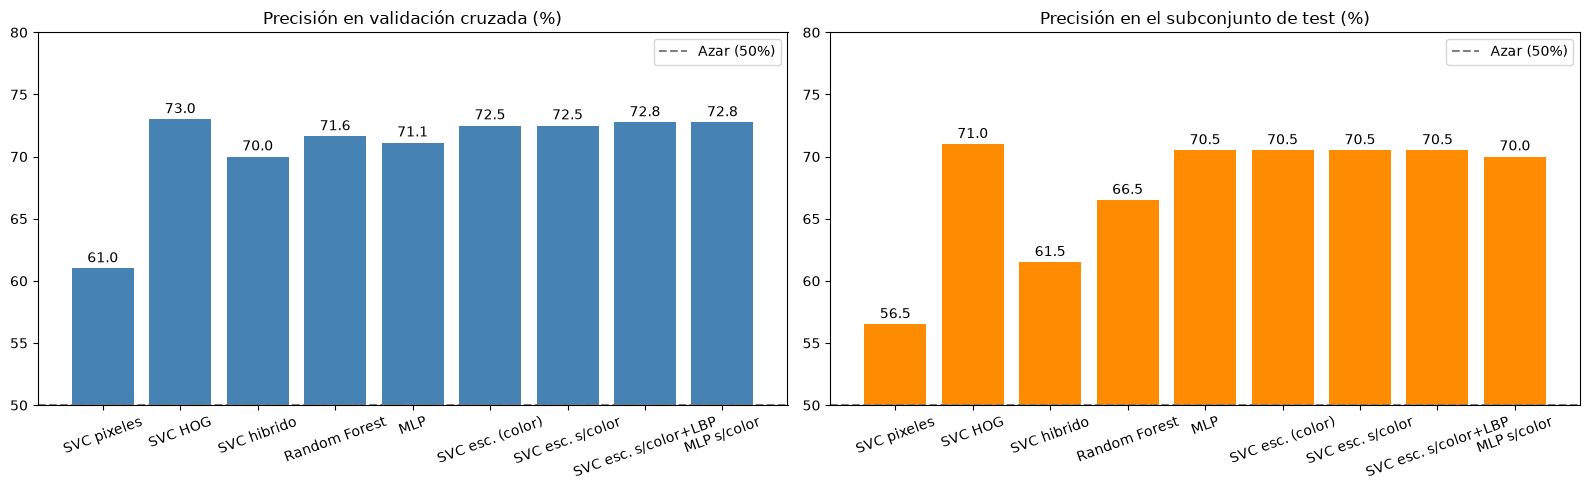

In [46]:
#Comparación de la precisión de todos los modelos probados

#Precisión en validación cruzada
cv_scores = {
    'SVC pixeles': 0.61,
    'SVC HOG': 0.73,
    'SVC hibrido': 0.70,
    'Random Forest': grid_rf.best_score_,
    'MLP': grid_mlp.best_score_,
    'SVC esc. (color)': grid_svc_esc.best_score_,
    'SVC esc. s/color': grid_svc_nc.best_score_,
    'SVC esc. s/color+LBP': grid_svc_lbp.best_score_,
    'MLP s/color': grid_mlp_nc.best_score_
}
#Precisión sobre el subconjunto de test
test_scores = {
    'SVC pixeles': accuracy,
    'SVC HOG': accuracy_hog,
    'SVC hibrido': accuracy_hibrido,
    'Random Forest': accuracy_rf,
    'MLP': accuracy_mlp,
    'SVC esc. (color)': accuracy_svc_esc,
    'SVC esc. s/color': accuracy_svc_nc,
    'SVC esc. s/color+LBP': accuracy_svc_lbp,
    'MLP s/color': accuracy_mlp_nc
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
etiquetas_cv = list(cv_scores.keys())
axes[0].bar(etiquetas_cv, [v * 100 for v in cv_scores.values()], color='steelblue')
axes[0].set_title('Precisión en validación cruzada (%)')
axes[0].set_ylim(50, 80)
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(50, color='gray', linestyle='--', label='Azar (50%)')
axes[0].legend()
for i, v in enumerate(cv_scores.values()):
    axes[0].text(i, v * 100 + 0.5, f'{v * 100:.1f}', ha='center')

etiquetas_test = list(test_scores.keys())
axes[1].bar(etiquetas_test, [v * 100 for v in test_scores.values()], color='darkorange')
axes[1].set_title('Precisión en el subconjunto de test (%)')
axes[1].set_ylim(50, 80)
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(50, color='gray', linestyle='--', label='Azar (50%)')
axes[1].legend()
for i, v in enumerate(test_scores.values()):
    axes[1].text(i, v * 100 + 0.5, f'{v * 100:.1f}', ha='center')

plt.tight_layout()
plt.show()

## Conclusiones finales

Tabla resumen de los nueve modelos entrenados (todos con la misma partición train/test y la misma estrategia de búsqueda en malla; los tres SVC originales usan validación cruzada de 2 folds y los seis modelos nuevos usan 5 folds, una estimación más fiable):

| Modelo | Características | Mejores hiperparámetros | Precisión CV | Precisión test |
|---|---|---|---|---|
| SVC píxeles planos | 67500 | kernel rbf | 61% | 56.5% |
| SVC HOG | 8100 | kernel poly | **73%** | **71%** |
| SVC HOG + Haralick + color | 8119 | kernel linear | 71% | 61.5% |
| Random Forest | 8119 | 100 árboles, sin límite de profundidad | 72% | 66.5% |
| MLP (red neuronal) | 8119 estandarizadas | capas (256, 128), alpha 0.001 | 71% | 70.5% |
| SVC híbrida + StandardScaler | 8119 estandarizadas | kernel rbf | 73% | 70.5% |
| SVC HOG+Haralick sin color + StandardScaler | 8113 estandarizadas | kernel rbf | 73% | 70.5% |
| MLP HOG+Haralick sin color | 8113 estandarizadas | capas (256, 128), alpha 0.001 | 73% | 70.0% |
| SVC HOG+Haralick+LBP sin color + StandardScaler | 8123 estandarizadas | kernel rbf | 73% | 70.5% |

**Fundamentación conceptual de los resultados:**

1. **El descriptor importa más que el clasificador.** El mayor salto de rendimiento no vino de cambiar de modelo, sino de cambiar de representación: de píxeles planos a HOG (61% a 73% en validación cruzada). La forma de orejas, cabeza y hocico que captura HOG es la pista dominante entre gatos y perros; los clasificadores solo pueden extraer la información que el descriptor les entrega.

2. **Todos los clasificadores convergen a un mismo techo (~70-73%).** Con el mismo vector de 8119 características, la SVC, el Random Forest y la MLP rinden de forma muy similar en validación cruzada (71%, 72% y 71%). Esto indica que el límite está en los datos (1000 imágenes) y en la información del vector, no en el algoritmo.

3. **La escala de las características afecta a los modelos basados en distancias/gradiente, pero no a los árboles.** El Random Forest, que decide por umbrales, no necesitó estandarización y aún así logró un 72% en validación cruzada. La MLP, que aprende por descenso de gradiente, requirió el Pipeline con StandardScaler y alcanzó el mejor test entre los modelos con el vector híbrido (70.5%), muy por encima del 61.5% de la SVC híbrida sin estandarizar. Aun así, la SVC con HOG puro (71% en test) sigue siendo el mejor modelo también sobre el subconjunto de test.

4. **Las estadísticas de color son redundantes en este problema.** Al aislar el color entrenando pares de modelos idénticos con y sin las 6 características de color, la SVC sin color rinde exactamente igual que con color (73% en validación cruzada y 70.5% en test en ambas), y en la MLP sin color la validación cruzada incluso mejora (73% vs 71%) con un test prácticamente idéntico (70.0% vs 70.5%). Esto confirma que la información discriminante está en la **forma (HOG)** y, en menor medida, en la **textura (Haralick)**, mientras que el color global aporta poco: los gatos y perros del conjunto de datos presentan pelajes de todos los colores, por lo que la tonalidad media no separa las clases.

5. **Cuidado con la varianza de las estimaciones.** Con solo 1000 imágenes, la diferencia entre la validación cruzada y el test puede ser notable: el Random Forest pasó de 72% (CV con cv=5) a 66.5% en test, y la MLP sin color de 73% a 70.0%. El Random Forest ilustra además otro fenómeno: en las distintas ejecuciones de este notebook la búsqueda en malla ha elegido combinaciones distintas (300 árboles sin límite de profundidad con cv=2, 100 árboles con profundidad 20 con cv=5 y Haralick manual, y 100 árboles sin límite ahora con mahotas), porque con tan pocos datos la estimación de cada combinación tiene una varianza alta. Con datasets pequeños, conviene interpretar las métricas con margen y no declarar un ganador por décimas de punto.

6. **Nueva apuesta: LBP.** Partiendo del mejor modelo de la tabla (la SVC estandarizada sin color), se añadió una novena SVC concatenando el histograma LBP al vector HOG + Haralick (8123 características en total) para comprobar si la textura local aporta información discriminante adicional. El resultado: kernel rbf, 73% en validación cruzada y 70.5% en test, idéntico a su par sin LBP. La textura local medida por LBP tampoco logra levantar el techo: HOG ya captura la mayor parte de la señal discriminante y los descriptores de textura, tanto globales (Haralick) como locales (LBP), añaden información redundante.

**Conclusión general:** para este problema, y sin recurrir todavía a aprendizaje profundo, el mejor modelo sigue siendo la **SVC con HOG** (73% en validación cruzada y 71% en test). Añadir textura de Haralick, estadísticas de color o textura local LBP a HOG no aportó información nueva discriminante, y cambiar de clasificador no levantó el techo. La vía más prometedora para superar el 73% sería aumentar la cantidad de imágenes (el dataset completo de Kaggle tiene miles por clase) o explorar descriptores más potentes, ya que el clasificador ya está aprovechando casi toda la información disponible en las características actuales.